In [7]:
import numpy as np
from scipy.constants import R
import matplotlib.pyplot as plt

from LJ_gas import (
    ParticleSystem, SimulationParameters,
    simulate_NVT_step, initialize_positions, initialize_velocities,
    calculate_force, potential_energy, kinetic_energy,
    instantaneous_temperature, density,
)

# argon params
mass_argon = 39.95
sigma_argon = 0.34            # nm
epsilon_argon = 120 * R * 1e-3   # kJ/mol

print("imports ok")

imports ok


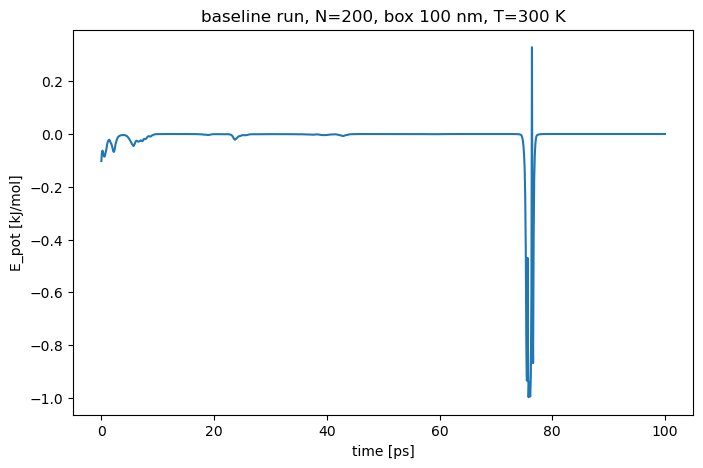

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# load the energy data the run saved. columns: E_pot, E_kin, T, P
ene = np.load("baseline_ene.npy")

dt = 0.1  # ps, same as in the run script
t = np.arange(ene.shape[0]) * dt  # time axis

# potential energy, no forced y limits this time
plt.figure(figsize=(8, 5))
plt.plot(t, ene[:, 0])
plt.xlabel("time [ps]")
plt.ylabel("E_pot [kJ/mol]")
plt.title("baseline run, N=200, box 100 nm, T=300 K")
plt.savefig("baseline_Epot_clean.png", dpi=200, bbox_inches="tight")
plt.show()

baseline run at defaults. E_pot sits at ~0 almost the whole time because the box
is huge and particles rarely meet. spikes = rare close encounters. not exploding,
not flat from being broken - flat because dilute..


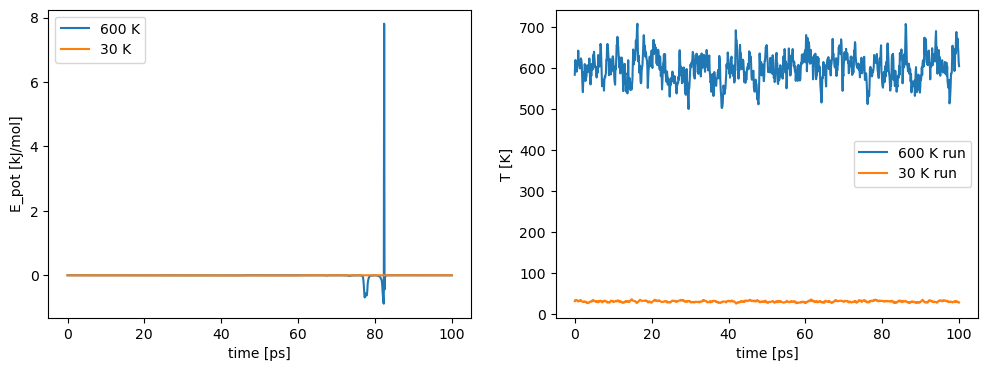

In [9]:
# compare E_pot for hot vs cold run
hot = np.load("hot_600K_ene.npy")
cold = np.load("cold_30K_ene.npy")
t = np.arange(hot.shape[0]) * 0.1  # ps

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(t, hot[:, 0], label="600 K")
ax[0].plot(t, cold[:, 0], label="30 K")
ax[0].set_xlabel("time [ps]")
ax[0].set_ylabel("E_pot [kJ/mol]")
ax[0].legend()

# temperature check - did the thermostat actually hold the targets
ax[1].plot(t, hot[:, 2], label="600 K run")
ax[1].plot(t, cold[:, 2], label="30 K run")
ax[1].set_xlabel("time [ps]")
ax[1].set_ylabel("T [K]")
ax[1].legend()

plt.savefig("hot_vs_cold.png", dpi=200, bbox_inches="tight")
plt.show()

hot 600 K vs cold 30 K at default density. E_pot flat at 0 for both, one lucky
collision in the hot run at ~82 ps. no clumping even at 30 K (argon boils at 87 K)
because the box is 100000x too dilute - particles never find each other.
thermostat confirmed working: T holds at both targets, bigger fluctuations at
600 K which is expected (fluctuation size scales with T).
conclusion for the project: condensation needs higher density. temperature alone
does nothing at this density

# phase 3 - cooling protocol

changes vs baseline: eps x3 (project hint), box 6 nm instead of 100 (density fix
from phase 2), dt 0.005 ps (dense system + stronger eps needs smaller timestep).
with eps x3, T* = T/360. plan: start ~400 K (T* 1.1, gas) and step down to
40 K (T* 0.11) in stages. snapshot positions at each stage, record E_pot every step.

In [11]:
def initialize_positions_lattice(ps, box_length):
    # put particles on a cubic grid so nothing starts overlapping.
    # random init in a small box = particles on top of each other = boom
    n_side = int(np.ceil(ps.n ** (1/3)))        # grid points per side (6 for 200)
    spacing = box_length / n_side               # 1 nm apart, ~3 sigma, safe
    points = []
    for ix in range(n_side):
        for iy in range(n_side):
            for iz in range(n_side):
                points.append([(ix + 0.5) * spacing,
                               (iy + 0.5) * spacing,
                               (iz + 0.5) * spacing])
    ps.position[:] = np.array(points[:ps.n])

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import R
from LJ_gas import (ParticleSystem, SimulationParameters, simulate_NVT_step,
                    initialize_positions, initialize_velocities,
                    calculate_force, potential_energy, instantaneous_temperature)

# system - denser box, beefed up epsilon
n_particles = 200
mass = 39.95
sigma = 0.34
epsilon = 3 * 120 * R * 1e-3   # 3x default. eps/kB now 360 K

box_length = 6.0     # nm. this is the density fix
dt = 0.005           # ps. small because dense + strong eps
steps_per_stage = 2000

# cooling schedule in K. T* = T/360
schedule = [400, 300, 220, 160, 120, 90, 60, 40]

sim = SimulationParameters(dt=dt, n_steps=steps_per_stage,
                           temperature=schedule[0],
                           box_length=box_length,
                           tau_thermostat=1, rij_min=1e-2)

ps = ParticleSystem(n_particles)
for i in range(n_particles):
    ps.set_parameters(i, mass=mass, sigma=sigma, epsilon=epsilon)

initialize_positions_lattice(ps, sim.box_length)
initialize_velocities(ps, sim.temperature)
calculate_force(ps, sim)

print("T* schedule:", [round(T/360, 2) for T in schedule])

T* schedule: [1.11, 0.83, 0.61, 0.44, 0.33, 0.25, 0.17, 0.11]


In [13]:
# cooling loop. lower the thermostat target stage by stage, run, snapshot
epot_trace = []       # E_pot every step, whole run
temp_trace = []       # actual T every step, to see the system chasing the target
snapshots = []        # positions at the end of each stage

for T_target in schedule:
    sim.temperature = T_target   # thermostat now pulls toward the new T
    for step in range(steps_per_stage):
        simulate_NVT_step(ps, sim)
        epot_trace.append(potential_energy(ps, sim))
        temp_trace.append(instantaneous_temperature(ps))
    snapshots.append(ps.position.copy())   # .copy() or every snapshot ends up identical
    print(f"stage {T_target} K done, E_pot = {epot_trace[-1]:.1f} kJ/mol")

epot_trace = np.array(epot_trace)
temp_trace = np.array(temp_trace)
np.save("cooling_epot.npy", epot_trace)
np.save("cooling_snapshots.npy", np.array(snapshots))

stage 400 K done, E_pot = -206.5 kJ/mol
stage 300 K done, E_pot = -274.1 kJ/mol
stage 220 K done, E_pot = -343.5 kJ/mol
stage 160 K done, E_pot = -699.1 kJ/mol
stage 120 K done, E_pot = -1186.6 kJ/mol
stage 90 K done, E_pot = -1545.3 kJ/mol
stage 60 K done, E_pot = -1810.4 kJ/mol
stage 40 K done, E_pot = -1976.4 kJ/mol


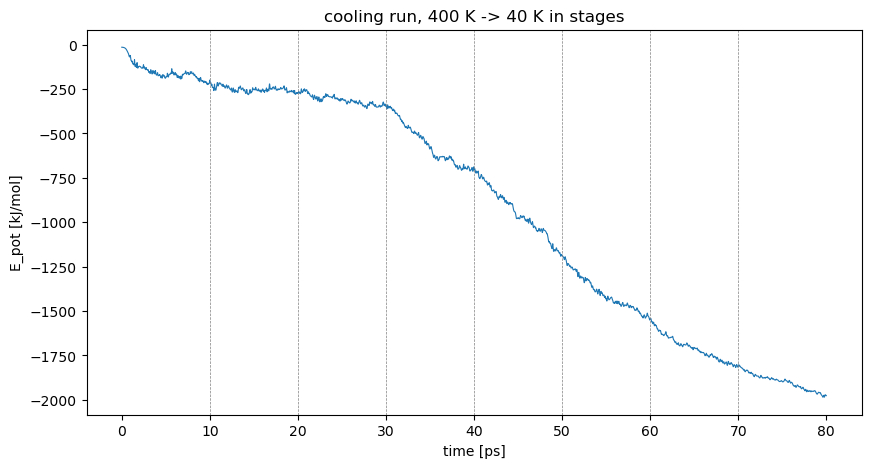

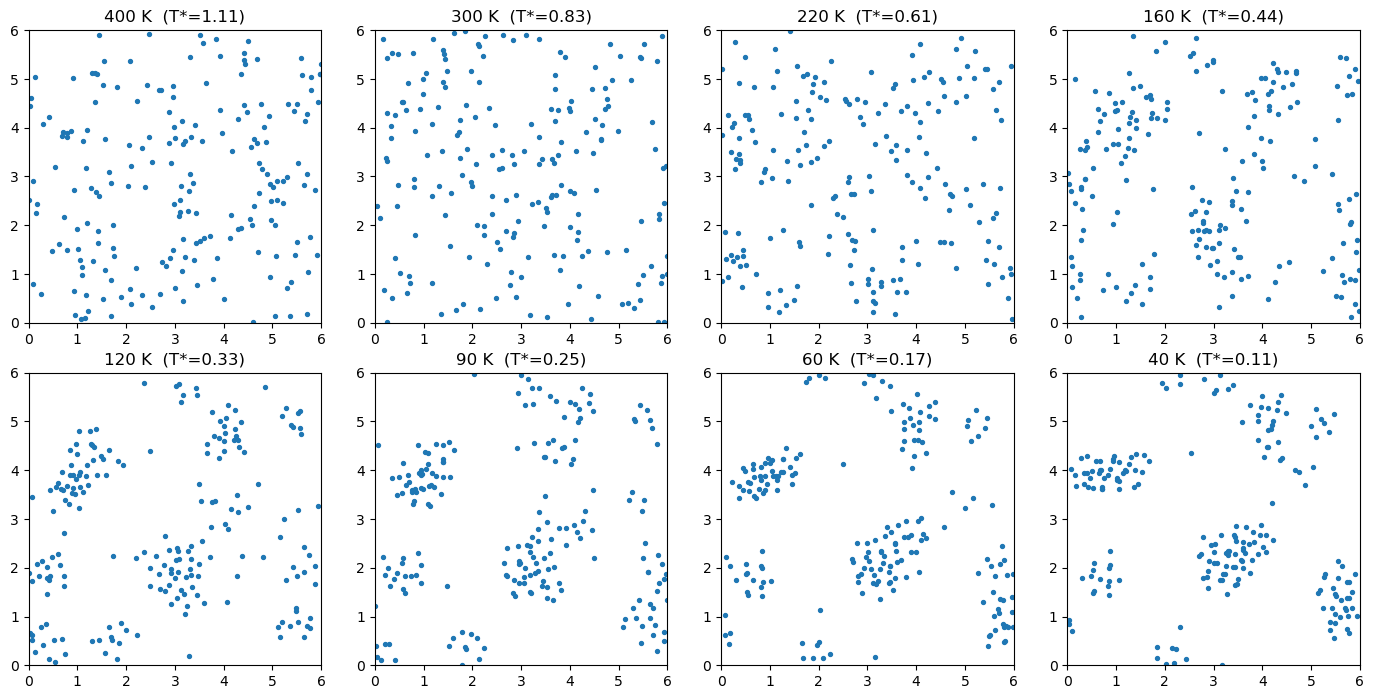

In [14]:
# full E_pot trace with stage boundaries
t = np.arange(len(epot_trace)) * dt
plt.figure(figsize=(10, 5))
plt.plot(t, epot_trace, lw=0.8)
for k in range(1, len(schedule)):
    plt.axvline(k * steps_per_stage * dt, color="gray", ls="--", lw=0.5)
plt.xlabel("time [ps]")
plt.ylabel("E_pot [kJ/mol]")
plt.title("cooling run, 400 K -> 40 K in stages")
plt.savefig("cooling_epot.png", dpi=200, bbox_inches="tight")
plt.show()

# snapshots - xy projection at each stage
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for k, ax in enumerate(axes.flat):
    pos = snapshots[k]
    ax.scatter(pos[:, 0], pos[:, 1], s=8)
    ax.set_title(f"{schedule[k]} K  (T*={schedule[k]/360:.2f})")
    ax.set_xlim(0, box_length); ax.set_ylim(0, box_length)
    ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("cooling_snapshots.png", dpi=200, bbox_inches="tight")
plt.show()

# phase 4 - analysis

4a: cluster finder. cluster = particles connected by pair distances below a
cutoff. cutoff = 1.5*sigma = 0.51 nm (a bit past r_min = 1.122 sigma, so
"touching or nearly touching" counts as bonded). has to use minimum image
convention, otherwise clusters spanning the box edge get cut in half.

In [15]:
# cluster finder. builds a "who is near who" matrix, then floods through
# neighbors to collect connected groups. no scipy magic, just BFS.

sigma = 0.34
cutoff = 1.5 * sigma   # nm. pairs closer than this count as bonded

def find_clusters(positions, box_length, cutoff):
    n = len(positions)

    # pairwise distance vectors, minimum image (same trick as calculate_force)
    rij = positions[:, np.newaxis, :] - positions[np.newaxis, :, :]
    rij -= box_length * np.rint(rij / box_length)
    dist = np.linalg.norm(rij, axis=-1)          # (n, n) distance matrix

    neighbors = dist < cutoff                     # True where pair is bonded
    np.fill_diagonal(neighbors, False)            # you are not your own neighbor

    # flood fill: grab an unvisited particle, collect everything reachable
    unvisited = set(range(n))
    clusters = []
    while unvisited:
        stack = [unvisited.pop()]
        cluster = [stack[0]]
        while stack:
            i = stack.pop()
            for j in np.where(neighbors[i])[0]:
                if j in unvisited:
                    unvisited.remove(j)
                    stack.append(j)
                    cluster.append(j)
        clusters.append(cluster)
    return clusters   # list of lists of particle indices

# quick test on first (hot) and last (cold) snapshot
snapshots = np.load("cooling_snapshots.npy")
box_length = 6.0
schedule = [400, 300, 220, 160, 120, 90, 60, 40]

for k in [0, len(snapshots) - 1]:
    cl = find_clusters(snapshots[k], box_length, cutoff)
    sizes = sorted([len(c) for c in cl], reverse=True)
    print(f"{schedule[k]} K: {len(cl)} clusters, biggest = {sizes[0]}, top 5 sizes = {sizes[:5]}")

400 K: 127 clusters, biggest = 7, top 5 sizes = [7, 6, 6, 5, 4]
40 K: 13 clusters, biggest = 54, top 5 sizes = [54, 35, 29, 18, 14]


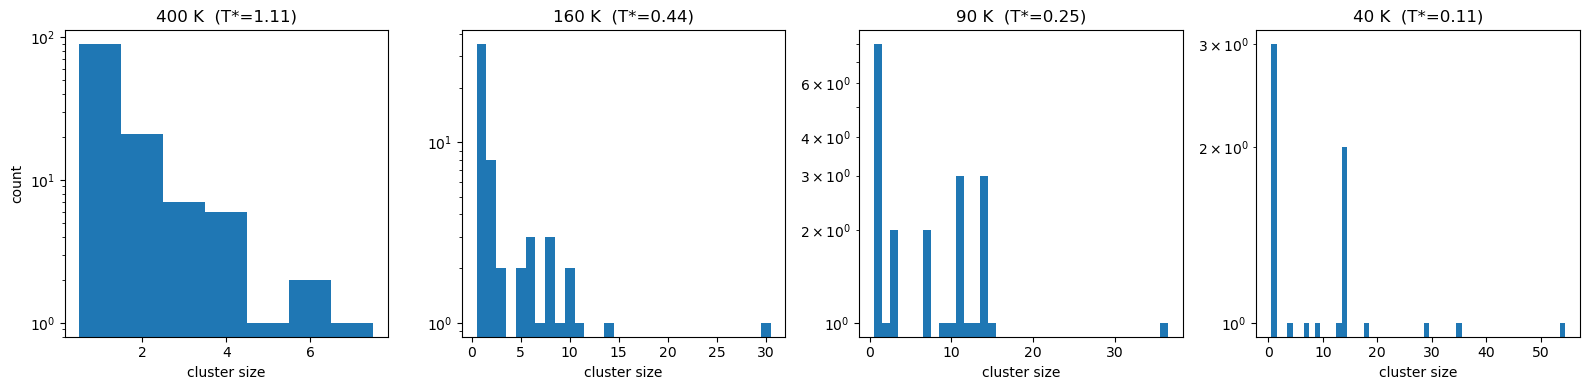

In [16]:
# cluster size histograms at 4 temperatures across the transition
pick = [0, 3, 5, 7]   # 400, 160, 90, 40 K

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, k in zip(axes, pick):
    sizes = [len(c) for c in find_clusters(snapshots[k], box_length, cutoff)]
    ax.hist(sizes, bins=np.arange(1, max(sizes) + 2) - 0.5)
    ax.set_title(f"{schedule[k]} K  (T*={schedule[k]/360:.2f})")
    ax.set_xlabel("cluster size")
    ax.set_yscale("log")   # log scale or the size-1 bar squashes everything
axes[0].set_ylabel("count")
plt.tight_layout()
plt.savefig("4a_cluster_size_dist.png", dpi=200, bbox_inches="tight")
plt.show()

4a: cluster size distribution across cooling. 400 K: 127 clusters, nothing
bigger than 7 - gas with brief sticking. 40 K: 13 clusters, biggest 54 -
basically all particles in droplets. several medium droplets instead of one
big one = fast quench, they nucleated separately and didnt merge. log y axis.

4b: potential energy evolution. full trace vs time, plus stage-averaged E_pot
vs temperature to locate where the drop is steepest = condensation transition.

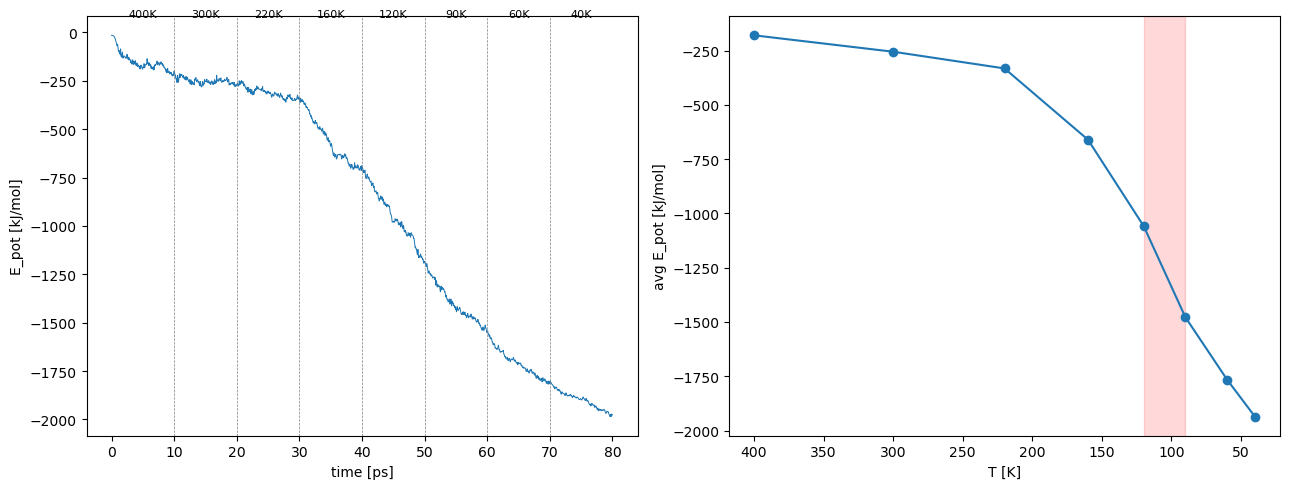

 400 K  (T*=1.11)  avg E_pot =   -179.7
 300 K  (T*=0.83)  avg E_pot =   -255.3
 220 K  (T*=0.61)  avg E_pot =   -332.2
 160 K  (T*=0.44)  avg E_pot =   -660.6
 120 K  (T*=0.33)  avg E_pot =  -1058.0
  90 K  (T*=0.25)  avg E_pot =  -1478.2
  60 K  (T*=0.17)  avg E_pot =  -1765.7
  40 K  (T*=0.11)  avg E_pot =  -1936.0

biggest drop: 120 K -> 90 K


In [17]:
epot = np.load("cooling_epot.npy")
dt = 0.005
steps_per_stage = 2000
schedule = [400, 300, 220, 160, 120, 90, 60, 40]
t = np.arange(len(epot)) * dt

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# left: full trace with stage boundaries and labels
ax[0].plot(t, epot, lw=0.7)
for k in range(1, len(schedule)):
    ax[0].axvline(k * steps_per_stage * dt, color="gray", ls="--", lw=0.5)
for k, T in enumerate(schedule):
    ax[0].text((k + 0.5) * steps_per_stage * dt, ax[0].get_ylim()[1] * 0.95,
               f"{T}K", ha="center", fontsize=8)
ax[0].set_xlabel("time [ps]")
ax[0].set_ylabel("E_pot [kJ/mol]")

# right: average E_pot over the last half of each stage (skip the settling-in part)
epot_stages = epot.reshape(len(schedule), steps_per_stage)
epot_avg = epot_stages[:, steps_per_stage // 2:].mean(axis=1)

drops = np.diff(epot_avg)              # change between consecutive stages
k_sharp = np.argmin(drops)             # index of the biggest drop

ax[1].plot(schedule, epot_avg, "o-")
ax[1].axvspan(schedule[k_sharp + 1], schedule[k_sharp], alpha=0.15, color="red")
ax[1].invert_xaxis()                   # so cooling reads left to right
ax[1].set_xlabel("T [K]")
ax[1].set_ylabel("avg E_pot [kJ/mol]")

plt.tight_layout()
plt.savefig("4b_epot_evolution.png", dpi=200, bbox_inches="tight")
plt.show()

for T, e in zip(schedule, epot_avg):
    print(f"{T:4d} K  (T*={T/360:.2f})  avg E_pot = {e:8.1f}")
print(f"\nbiggest drop: {schedule[k_sharp]} K -> {schedule[k_sharp+1]} K")

4b: E_pot during cooling. shallow slope while gas (400-220 K, ~-75 per stage),
then the curve bends at 220 K (T* 0.61) and drops hard: -330 to -420 per stage
through 120->90 K (red band = biggest single drop). thats condensation, binding
energy released. note E_pot never flattens within the steep stages - system is
still condensing when the next T drop hits. fast quench, matches the multiple
unmerged droplets from 4a. slope eases again below 90 K, droplets just compacting.

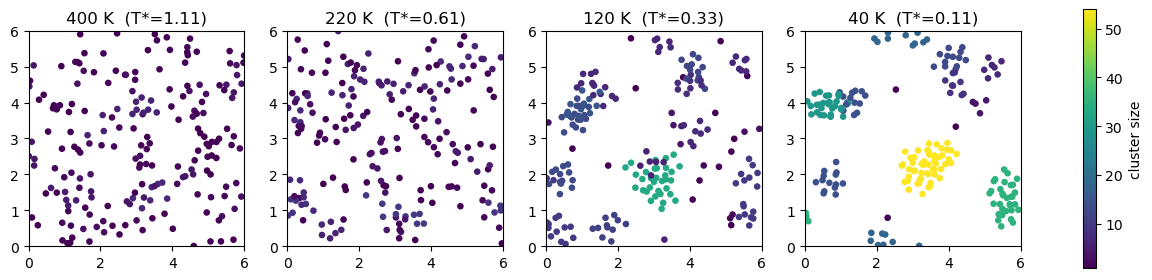

In [19]:
pick = [0, 2, 4, 7]

# global max cluster size across the picked snapshots, so all panels share one scale
all_sizes = []
size_maps = []
for k in pick:
    clusters = find_clusters(snapshots[k], box_length, cutoff)
    size_of = np.zeros(len(snapshots[k]))
    for c in clusters:
        for i in c:
            size_of[i] = len(c)
    size_maps.append(size_of)
    all_sizes.append(size_of.max())
vmax = max(all_sizes)

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, k, size_of in zip(axes, pick, size_maps):
    pos = snapshots[k]
    sc = ax.scatter(pos[:, 0], pos[:, 1], c=size_of, cmap="viridis", s=14,
                    vmin=1, vmax=vmax)
    ax.set_title(f"{schedule[k]} K  (T*={schedule[k]/360:.2f})")
    ax.set_xlim(0, box_length); ax.set_ylim(0, box_length)
    ax.set_aspect("equal")
fig.colorbar(sc, ax=axes, label="cluster size", shrink=0.8)
plt.savefig("4c_condensation_strip.png", dpi=200, bbox_inches="tight")
plt.show()

4c: gas -> condensed, colored by cluster size, one shared color scale (had a bug
first where each panel scaled its own colors - 400 K looked like it had big
clusters, it doesnt, max is 7). 400 K near-all purple singles. 220 K first
teal groups. 120 K droplets, the size-54 one going yellow. 40 K few big
droplets, gas gone. 2d projection of 3d box so some overlap is fake.

4d: largest cluster size vs temperature. order parameter for the transition -
should sit near 1-10 in the gas, then jump up through the condensation window.

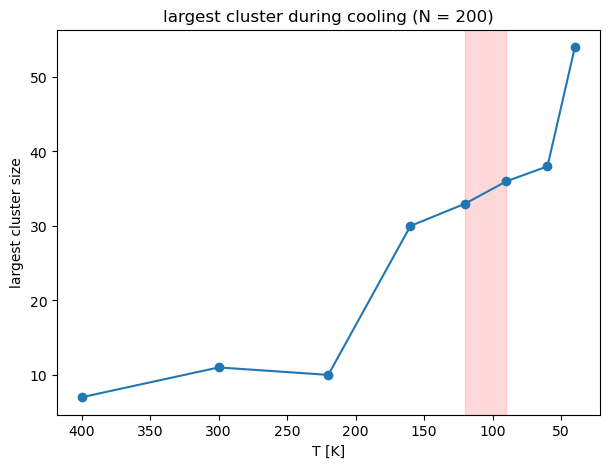

 400 K  (T*=1.11)  largest = 7
 300 K  (T*=0.83)  largest = 11
 220 K  (T*=0.61)  largest = 10
 160 K  (T*=0.44)  largest = 30
 120 K  (T*=0.33)  largest = 33
  90 K  (T*=0.25)  largest = 36
  60 K  (T*=0.17)  largest = 38
  40 K  (T*=0.11)  largest = 54


In [20]:
# 4d: biggest cluster at every stage
largest = []
for snap in snapshots:
    clusters = find_clusters(snap, box_length, cutoff)
    largest.append(max(len(c) for c in clusters))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(schedule, largest, "o-")
ax.axvspan(120, 90, alpha=0.15, color="red")   # 4b's biggest E_pot drop
ax.invert_xaxis()   # cooling reads left to right
ax.set_xlabel("T [K]")
ax.set_ylabel("largest cluster size")
ax.set_title("largest cluster during cooling (N = 200)")
plt.savefig("4d_largest_cluster.png", dpi=200, bbox_inches="tight")
plt.show()

for T, s in zip(schedule, largest):
    print(f"{T:4d} K  (T*={T/360:.2f})  largest = {s}")

4d: largest cluster vs T. small (7-11) in the gas, jumps 10->30 at 220->160 K =
structural onset, right where the 4b E_pot curve starts bending. then plateaus
30-38 while E_pot keeps dropping hard - that energy is the OTHER droplets growing,
not the biggest one. final hop 38->54 at 60->40 K looks like two droplets merging.
no single sharp cliff: N=200 + fast quench smears the transition.

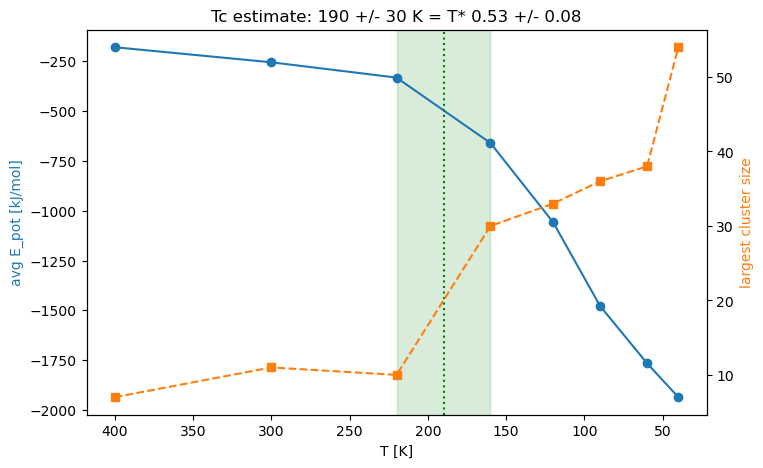

In [21]:
# phase 5: Tc estimate. overlay both order parameters vs T
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(schedule, epot_avg, "o-", color="tab:blue", label="avg E_pot")
ax1.set_xlabel("T [K]")
ax1.set_ylabel("avg E_pot [kJ/mol]", color="tab:blue")
ax1.invert_xaxis()

ax2 = ax1.twinx()
ax2.plot(schedule, largest, "s--", color="tab:orange", label="largest cluster")
ax2.set_ylabel("largest cluster size", color="tab:orange")

# our estimate: transition bracketed by 220 and 160 K
ax1.axvspan(220, 160, alpha=0.15, color="green")
ax1.axvline(190, color="green", ls=":")
ax1.set_title("Tc estimate: 190 +/- 30 K = T* 0.53 +/- 0.08")

plt.savefig("5_Tc_estimate.png", dpi=200, bbox_inches="tight")
plt.show()

## phase 5 - critical temperature
- estimate: Tc ~ 190 +/- 30 K = T* 0.53 +/- 0.08. bracketed by the E_pot bend
  and the largest-cluster jump, both between 220 and 160 K stages. uncertainty
  = stage spacing, we only sampled every ~50 K there
- literature LJ critical point is T* ~ 1.3. ours is lower and thats expected,
  not wrong:
  1. what we measure is the CONDENSATION temperature at our specific density
     (0.06 g/cm^3, dilute), not the critical point. below critical density the
     gas condenses at a T below Tc - we are on the coexistence curve, not at
     its top
  2. fast quench = supercooling. nucleation lags, transition shows up colder
     than equilibrium
  3. N = 200 finite size smears and shifts everything

# phase 5 step 4 - epsilon sanity check
prediction: Tc in kelvin scales with eps, Tc* stays put. 3x run gave T* ~0.53.
2x run (eps/kB = 240 K) should transition near 0.53*240 ~ 125 K.
schedule below = 3x schedule scaled by 2/3 so it brackets the transition the same way.

In [22]:
# fresh system with eps x2. everything suffixed _2x so the 3x results survive
epsilon_2x = 2 * 120 * R * 1e-3          # eps/kB = 240 K
schedule_2x = [270, 200, 145, 105, 80, 60, 40, 27]   # 2/3 of the 3x schedule

sim2 = SimulationParameters(dt=dt, n_steps=steps_per_stage,
                            temperature=schedule_2x[0],
                            box_length=box_length,
                            tau_thermostat=1, rij_min=1e-2)

ps2 = ParticleSystem(n_particles)
for i in range(n_particles):
    ps2.set_parameters(i, mass=mass, sigma=sigma, epsilon=epsilon_2x)

initialize_positions_lattice(ps2, sim2.box_length)
initialize_velocities(ps2, sim2.temperature)
calculate_force(ps2, sim2)

print("T* schedule:", [round(T/240, 2) for T in schedule_2x])

T* schedule: [1.12, 0.83, 0.6, 0.44, 0.33, 0.25, 0.17, 0.11]


In [23]:
epot_2x = []
snapshots_2x = []

for T_target in schedule_2x:
    sim2.temperature = T_target
    for step in range(steps_per_stage):
        simulate_NVT_step(ps2, sim2)
        epot_2x.append(potential_energy(ps2, sim2))
    snapshots_2x.append(ps2.position.copy())
    print(f"stage {T_target} K done, E_pot = {epot_2x[-1]:.1f} kJ/mol")

epot_2x = np.array(epot_2x)
np.save("cooling2x_epot.npy", epot_2x)
np.save("cooling2x_snapshots.npy", np.array(snapshots_2x))

stage 270 K done, E_pot = -120.9 kJ/mol
stage 200 K done, E_pot = -140.9 kJ/mol
stage 145 K done, E_pot = -193.5 kJ/mol
stage 105 K done, E_pot = -330.7 kJ/mol
stage 80 K done, E_pot = -561.7 kJ/mol
stage 60 K done, E_pot = -887.1 kJ/mol
stage 40 K done, E_pot = -1085.4 kJ/mol
stage 27 K done, E_pot = -1172.4 kJ/mol


In [24]:
# stage averages + largest cluster for the 2x run
epot_stages_2x = epot_2x.reshape(len(schedule_2x), steps_per_stage)
epot_avg_2x = epot_stages_2x[:, steps_per_stage // 2:].mean(axis=1)

largest_2x = []
for snap in snapshots_2x:
    clusters = find_clusters(snap, box_length, cutoff)
    largest_2x.append(max(len(c) for c in clusters))

for T, e, s in zip(schedule_2x, epot_avg_2x, largest_2x):
    print(f"{T:4d} K  (T*={T/240:.2f})  avg E_pot = {e:8.1f}   largest = {s}")

 270 K  (T*=1.12)  avg E_pot =   -110.3   largest = 6
 200 K  (T*=0.83)  avg E_pot =   -128.0   largest = 7
 145 K  (T*=0.60)  avg E_pot =   -173.3   largest = 11
 105 K  (T*=0.44)  avg E_pot =   -293.6   largest = 25
  80 K  (T*=0.33)  avg E_pot =   -528.1   largest = 25
  60 K  (T*=0.25)  avg E_pot =   -818.6   largest = 28
  40 K  (T*=0.17)  avg E_pot =  -1057.2   largest = 29
  27 K  (T*=0.11)  avg E_pot =  -1168.4   largest = 29


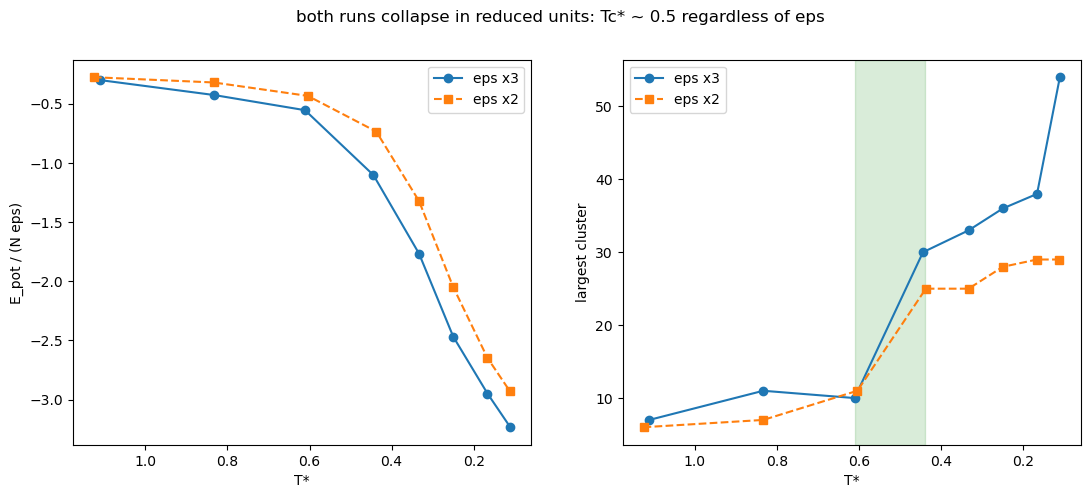

In [25]:

# the collapse plot: both runs vs reduced temperature
Tstar_3x = np.array(schedule) / 360
Tstar_2x = np.array(schedule_2x) / 240

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# E_pot per particle per epsilon, so energies are in reduced units too
eps3 = 3 * 120 * R * 1e-3
ax[0].plot(Tstar_3x, epot_avg / (n_particles * eps3), "o-", label="eps x3")
ax[0].plot(Tstar_2x, epot_avg_2x / (n_particles * epsilon_2x), "s--", label="eps x2")
ax[0].set_xlabel("T*")
ax[0].set_ylabel("E_pot / (N eps)")
ax[0].invert_xaxis()
ax[0].legend()

ax[1].plot(Tstar_3x, largest, "o-", label="eps x3")
ax[1].plot(Tstar_2x, largest_2x, "s--", label="eps x2")
ax[1].axvspan(0.61, 0.44, alpha=0.15, color="green")
ax[1].set_xlabel("T*")
ax[1].set_ylabel("largest cluster")
ax[1].invert_xaxis()
ax[1].legend()

plt.suptitle("both runs collapse in reduced units: Tc* ~ 0.5 regardless of eps")
plt.savefig("5_epsilon_collapse.png", dpi=200, bbox_inches="tight")
plt.show()

5: collapse plot. both runs vs reduced temperature, E_pot also reduced (per
particle per eps). curves nearly collapse - transition at the same T* ~0.5
(green band) for both eps values, so eps just sets the energy scale. small
E_pot offset and the cold-end split in largest cluster = single runs, fast
quench, no equilibration - the 3x run got a lucky droplet merge, the 2x
didnt. universality is in where the jump is, not in the final droplet.
